In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from tqdm.notebook import tqdm

from src.koppen_geiger import (
    KOPPEN_DESCRIPTION,
    analyse_koppen_geiger,
    load_koppen_pickles_from_folder,
    plot_climate_class_timeseries,
)
from src.paths import *

In [2]:
# folder with shapefiles
test_path = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools/shapefiles_converter"
)


# Define shapefiles (adjust paths if needed)
shapefiles = {
    "test1": {
        "path": test_path / "id_1.shp",
        "edgecolor": "black",
        "linewidth": 2,
        "linestyle": "-",
    },
    "test2": {"path": test_path / "id_2.shp", "edgecolor": "blue", "linewidth": 2},
    "test3": {"path": test_path / "id_5.shp", "edgecolor": "red", "linewidth": 2},
}

# Find all raster files,
files = sorted(KOPPEN_GEIGER.rglob("koppen_geiger_0p00833333.tif"))

# Directories for saving outputs
save_dir = KOPPEN_FIGURES / "test_for_ewc_lowres_18"
save_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# shapefile_dir_aral = SHAPEFILES

# # shapefiles_aral = list(shapefile_dir_aral.glob("*.shp"))
# # print(shapefiles_aral)


# shapefile_list = sorted(test_path.rglob("*.shp"))

# shapefiles_dict = {shp.stem: {"path": shp} for shp in shapefile_list}

In [4]:
for shapename, shp_cfg in tqdm(
    shapefiles.items(), total=len(shapefiles), desc="total koppen-geiger analysis", position=0
):
    shapefile_save_dir = save_dir / shapename
    shapefile_save_dir.mkdir(parents=True, exist_ok=True)

    for path in tqdm(
        files,
        total=len(files),
        desc=f"current shapefile = {shapename}.shp",
        position=1,
        leave=False,  # prevents clutter after finishing inner loop
    ):
        df_percent, top_df = analyse_koppen_geiger(
            path_to_file=path,
            shapefiles={shapename: shp_cfg},
            koppen_description=KOPPEN_DESCRIPTION,
            plot_map=True,
            plot_hist=True,
            generate_table=True,
            save_dir=shapefile_save_dir,
            show_plot=False,
            return_fig=False,
        )

total koppen-geiger analysis:   0%|          | 0/3 [00:00<?, ?it/s]

current shapefile = test1.shp:   0%|          | 0/18 [00:00<?, ?it/s]

current shapefile = test2.shp:   0%|          | 0/18 [00:00<?, ?it/s]

current shapefile = test3.shp:   0%|          | 0/18 [00:00<?, ?it/s]

In [5]:
shapefile_save_dir = save_dir / "combined"
shapefile_save_dir.mkdir(parents=True, exist_ok=True)

for path in tqdm(
    files,
    total=len(files),
    desc="combined",
):
    df_percent, top_df = analyse_koppen_geiger(
        path_to_file=path,
        shapefiles=shapefiles,
        koppen_description=KOPPEN_DESCRIPTION,
        plot_map=True,
        plot_hist=True,
        generate_table=True,
        save_dir=shapefile_save_dir,
        show_plot=False,
        return_fig=False,
    )

combined:   0%|          | 0/18 [00:00<?, ?it/s]

In [2]:
pkl_folder = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger/test_for_ewc_lowres_16/Garm_GRDC/"
test_func = load_koppen_pickles_from_folder(pkl_folder)
test_func.tail()

,Plotted Area,Garm_GRDC,climate_class,period,ssp,year_start,year_middle,year_end,description
531,0.000000,0.000000,Dwb,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, warm summer"
532,0.026761,0.000000,Dwc,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, cold summer"
533,0.000000,0.000000,Dwd,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, very cold winter"
539,0.069498,0.411495,EF,2071_2099,SSP585,2071,2085,2099,Ice cap
538,11.614903,27.719776,ET,2071_2099,SSP585,2071,2085,2099,Tundra


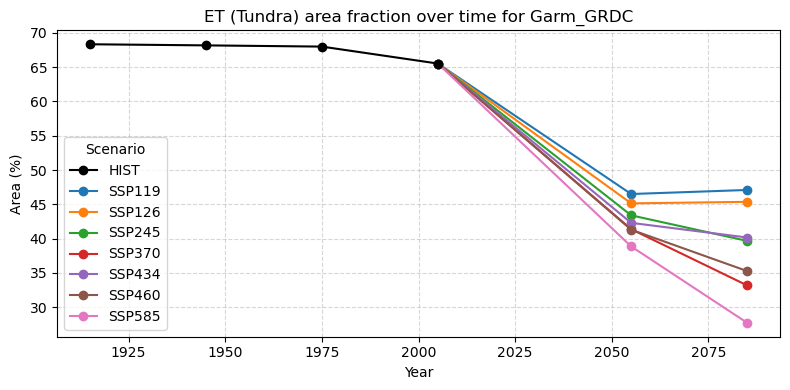

In [3]:
fig, ax = plot_climate_class_timeseries(
    test_func,
    column_name="Garm_GRDC",
    climate_class="ET",
)